<a href="https://colab.research.google.com/github/slr549/Machine-Learning-Course-2026/blob/main/assignments/week-07/2411070095_Raki%20Raihan/Ra.Han_07_MLP_Digit_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setup & Load MNIST Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import fetch_openml
import wandb

# Inisialisasi W&B
run = wandb.init(project="mnist-neural-networks", name="mlp-baseline")

# Load MNIST Dataset (Angka 0-9)
print("Loading MNIST data... (Mohon tunggu)")
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='auto')

# Normalisasi: Mengubah rentang pixel 0-255 menjadi 0-1 agar NN belajar lebih cepat
X = X / 255.0

print(f"Data Loaded. Shape: {X.shape}")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: han-dev321 (han-dev321-stikomelrahma) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Loading MNIST data... (Mohon tunggu)
Data Loaded. Shape: (70000, 784)


Visualisasi Data Tulisan Tangan

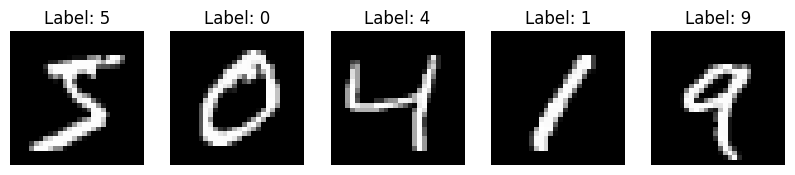

In [ ]:
# Mari kita lihat apa yang dilihat oleh AI
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
plt.show()

# Log contoh gambar ke W&B
wandb.log({"mnist_examples": [wandb.Image(X[i].reshape(28, 28), caption=f"Label: {y[i]}") for i in range(5)]})

Pelatihan Multi-Layer Perceptron

In [ ]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Membangun Arsitektur Jaringan Saraf
# hidden_layer_sizes=(128, 64) artinya ada 2 hidden layer dengan 128 dan 64 neuron
mlp = MLPClassifier(hidden_layer_sizes=(128, 64),
                    activation='relu',
                    solver='adam',
                    learning_rate_init=0.001, # Kecepatan belajar awal
                    alpha=0.0001, # Tambahkan ini: L2 Penalty (Regularisasi)
                    max_iter=20, # Kita batasi iterasi agar cepat untuk latihan
                    verbose=True,
                    random_state=42)

print("Melatih Jaringan Saraf...")
mlp.fit(X_train, y_train)

Melatih Jaringan Saraf...
Iteration 1, loss = 0.39286260
Iteration 2, loss = 0.15239755
Iteration 3, loss = 0.10608706
Iteration 4, loss = 0.08038778
Iteration 5, loss = 0.06403363
Iteration 6, loss = 0.05088564
Iteration 7, loss = 0.04088828
Iteration 8, loss = 0.03441392
Iteration 9, loss = 0.02911492
Iteration 10, loss = 0.02490929
Iteration 11, loss = 0.01988026
Iteration 12, loss = 0.01600589
Iteration 13, loss = 0.01437448
Iteration 14, loss = 0.01047791
Iteration 15, loss = 0.01086533
Iteration 16, loss = 0.00985182
Iteration 17, loss = 0.00891190
Iteration 18, loss = 0.00688038
Iteration 19, loss = 0.00833706
Iteration 20, loss = 0.00814995


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=20, random_state=42,
              verbose=True)

Evaluasi & Tracking W&B

In [ ]:
y_pred = mlp.predict(X_test)
acc = accuracy_score(y_test, y_pred)

# Log kurva kehilangan (Loss Curve) yang menunjukkan proses belajar
for i, loss in enumerate(mlp.loss_curve_):
    wandb.log({"loss": loss, "epoch": i})

wandb.log({"Final_Accuracy": acc})

print(f"\nAkurasi MLP: {acc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Akurasi MLP: 0.9724

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1343
           1       0.98      0.99      0.98      1600
           2       0.93      0.99      0.96      1380
           3       0.98      0.97      0.97      1433
           4       0.97      0.98      0.97      1295
           5       0.98      0.97      0.97      1273
           6       0.97      0.99      0.98      1396
           7       0.99      0.94      0.96      1503
           8       0.97      0.95      0.96      1357
           9       0.97      0.95      0.96      1420

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



Analisis Kesalahan (Confusion Matrix)

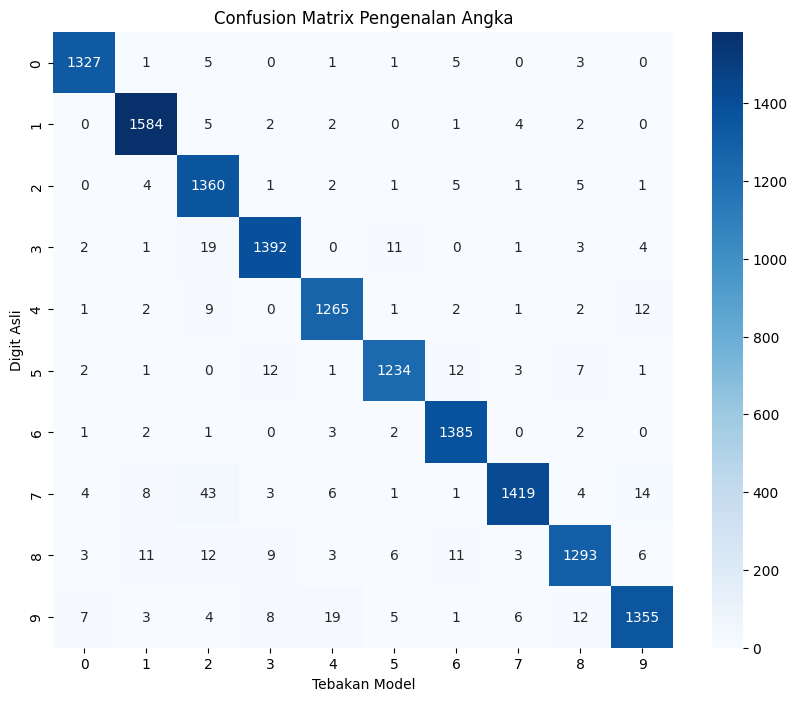

Final_Accuracy,▁
epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
loss,█▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
Final_Accuracy,0.97243
epoch,19
loss,0.00815


In [ ]:
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Tebakan Model')
plt.ylabel('Digit Asli')
plt.title('Confusion Matrix Pengenalan Angka')
plt.show()

wandb.finish()